# Spotify Music Performance Analysis

Este notebook apresenta a exploração analítica dos fatores que influenciam o desempenho musical no Spotify.

Objetivos:
- analisar impacto de playlists;
- avaliar influência dos charts;
- entender comportamento por gênero;
- identificar padrões de alcance global;
- explorar fatores relacionados ao crescimento de streams.

## 1. Importação das bibliotecas a serem usadas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

## 2. Carregamento da base

In [2]:
df = pd.read_csv(
    "Base_Spotify.csv",
    sep=",",
    quotechar='"',
    encoding="utf-8"
)

## 3. Entendimento inicial da base

df.head()
df.info()
df.shape

In [3]:
df.head()

,track_id,track_name,track_name_limpo,artists_name,artist_count,tipo_colaboracao,main_music_genre_tratado,main_country_tratado,released_year,released_month,...,presenca_spotify,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,playlists_total_outros,charts_total_outros,presenca_total_outros,presenca_total_global
0,6909746,White Christmas,White Christmas,"Bing Crosby, John Scott Trotter & His Orchestr...",3,Colaboração (3+),Christmas traditional,United States,1942,1,...,11940,73,79,123,0,0,196,79,275,12215
1,3087104,The Christmas Song (Merry Christmas To You) - ...,The Christmas Song,Nat King Cole,1,Solo,Christmas jazz,United States,1946,11,...,11500,140,72,251,0,0,391,72,463,11963
2,8753775,Let It Snow! Let It Snow! Let It Snow!,Let It Snow! Let It Snow! Let It Snow!,"Frank Sinatra, B. Swanson Quartet",2,Dupla,Christmas pop,United States,1950,1,...,10585,126,108,406,0,0,532,108,640,11225
3,4002890,A Holly Jolly Christmas - Single Version,A Holly Jolly Christmas,Burl Ives,1,Solo,Christmas traditional,United States,1952,1,...,7930,108,120,73,0,0,181,120,301,8231
4,6372609,Jingle Bell Rock,Jingle Bell Rock,Bobby Helms,1,Solo,Christmas rock,United States,1957,1,...,10326,165,99,104,0,0,269,99,368,10694


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  839 non-null    int64  
 1   track_name                839 non-null    object 
 2   track_name_limpo          839 non-null    object 
 3   artists_name              839 non-null    object 
 4   artist_count              839 non-null    int64  
 5   tipo_colaboracao          839 non-null    object 
 6   main_music_genre_tratado  839 non-null    object 
 7   main_country_tratado      839 non-null    object 
 8   released_year             839 non-null    int64  
 9   released_month            839 non-null    int64  
 10  released_day              839 non-null    int64  
 11  faixa_lancamento          839 non-null    object 
 12  in_spotify_playlists      839 non-null    int64  
 13  in_spotify_charts         839 non-null    int64  
 14  streams_tr

In [5]:
df.isnull().sum()

,0
track_id,0
track_name,0
track_name_limpo,0
artists_name,0
artist_count,0
tipo_colaboracao,0
main_music_genre_tratado,0
main_country_tratado,0
released_year,0
released_month,0


In [6]:
df.duplicated().sum()

np.int64(0)

## 4. Limpeza e Tratamento dos Dados

Nesta etapa foram realizados:

- remoção de registros inconsistentes;
- exclusão de países classificados como "Unknown";
- remoção de registros duplicados;
- validação de valores nulos;
- padronização da base para análise exploratória.

In [7]:
df = df.drop(columns=['rn'])

In [8]:
df.isnull().sum()

,0
track_id,0
track_name,0
track_name_limpo,0
artists_name,0
artist_count,0
tipo_colaboracao,0
main_music_genre_tratado,0
main_country_tratado,0
released_year,0
released_month,0


In [9]:
df = df[df['track_id'] != 7173596]

In [10]:
df[df['track_id'] == 7173596]

,track_id,track_name,track_name_limpo,artists_name,artist_count,tipo_colaboracao,main_music_genre_tratado,main_country_tratado,released_year,released_month,...,presenca_spotify,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,playlists_total_outros,charts_total_outros,presenca_total_outros,presenca_total_global


In [11]:
df = df[df['main_country_tratado'] != 'Unknown']

In [12]:
df[df['main_country_tratado'] == 'Unknown']

,track_id,track_name,track_name_limpo,artists_name,artist_count,tipo_colaboracao,main_music_genre_tratado,main_country_tratado,released_year,released_month,...,presenca_spotify,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,playlists_total_outros,charts_total_outros,presenca_total_outros,presenca_total_global


In [14]:
df.shape

(837, 29)

In [50]:
df.isnull().sum().sort_values(ascending=False)

,0
streams_por_playlist,311
taxa_charts,311
log_streams,311
streams_tratado,311
released_month,310
main_music_genre_tratado,310
main_country_tratado,310
released_year,310
track_name_limpo,310
artists_name,310


### 4.1. Qualidade dos Dados
Observou-se a presença de valores nulos principalmente em variáveis derivadas,
como log_streams, taxa_charts e streams_por_playlist.

Esses valores são esperados devido a cálculos matemáticos envolvendo:
- divisão por zero;
- ausência de streams;
- ausência de presença em playlists/charts.

Como a base principal permaneceu íntegra, os registros foram mantidos
para preservar a consistência analítica do projeto.

In [15]:
# Valores nulos por coluna

df.isnull().sum().sort_values(ascending=False)

,0
streams_tratado,1
streams_por_playlist,1
taxa_charts,1
log_streams,1
track_id,0
tipo_colaboracao,0
main_music_genre_tratado,0
main_country_tratado,0
released_year,0
track_name,0


# 5. Análise Exploratória dos Dados

Nesta etapa foram realizadas análises exploratórias para identificar padrões relacionados ao desempenho musical no Spotify, considerando streams, playlists, charts, gêneros musicais e presença multiplataforma.

## 5.1 Distribuição dos Streams

In [17]:
# Removendo registros sem dado para análises numéricas

df_graficos = df[df['streams_tratado'] != 'Sem dados'].copy()

In [18]:
df_graficos['streams_tratado'] = pd.to_numeric(
    df_graficos['streams_tratado'],
    errors='coerce'
)

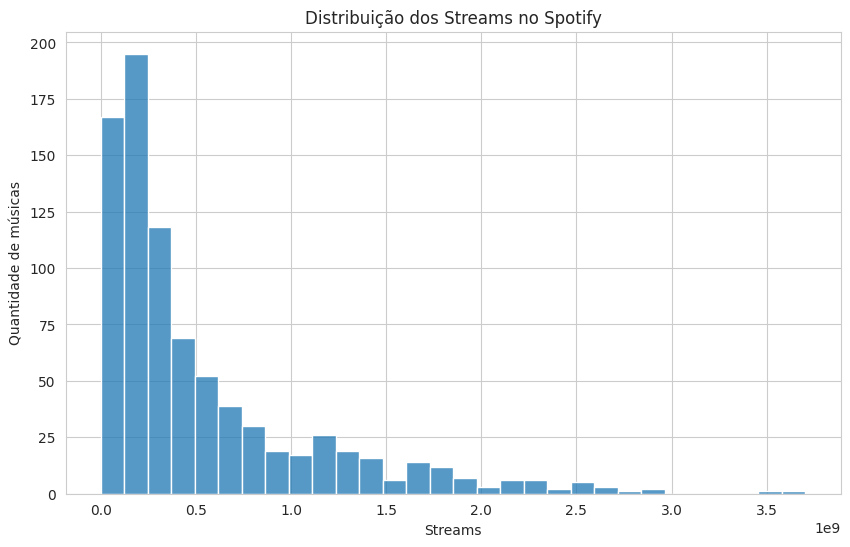

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_graficos['streams_tratado'],
    bins=30
)

plt.title('Distribuição dos Streams no Spotify')
plt.xlabel('Streams')
plt.ylabel('Quantidade de músicas')

plt.show()

### Insights

A distribuição dos Streams apresenta forte assimetria à direita,
indicando que poucas músicas concentram volumes extremamente altos de Streams,
enquanto a maior parte possui desempenho moderado.

Esse comportamento é comum em plataformas digitais,
onde sucessos globais concentram grande parte do consumo musical.

## 5.2 Top Gêneros Musicais

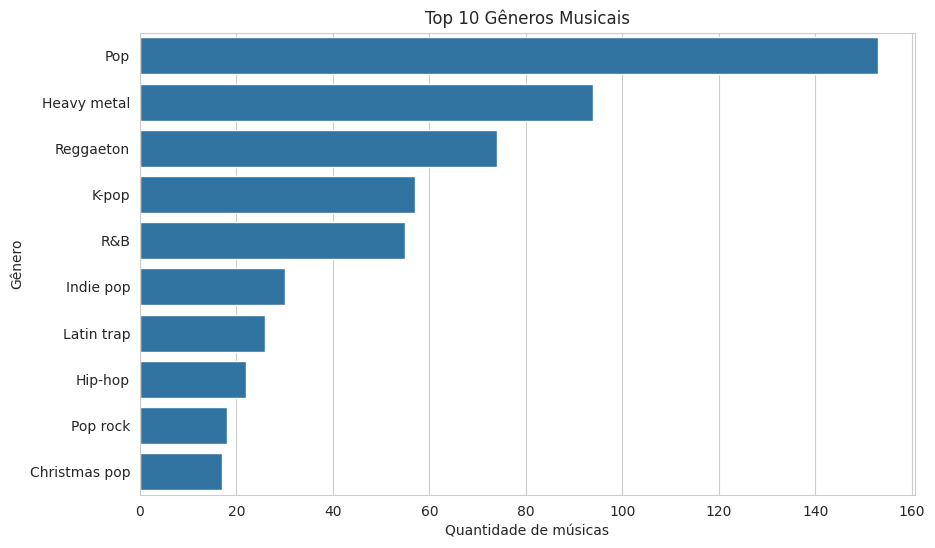

In [20]:
top_generos = (
    df_graficos['main_music_genre_tratado']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_generos.values,
    y=top_generos.index
)

plt.title('Top 10 Gêneros Musicais')
plt.xlabel('Quantidade de músicas')
plt.ylabel('Gênero')

plt.show()

### Insights

Os gêneros mais frequentes demonstram predominância de estilos
ligados ao pop, rap e EDM na base analisada.

Entretanto, frequência não necessariamente representa maior desempenho médio em streams,
como observado nos dashboards estratégicos, onde alguns gêneros de nicho apresentam médias superiores.

## 5.3 Streams x Playlists (Scatterplot)

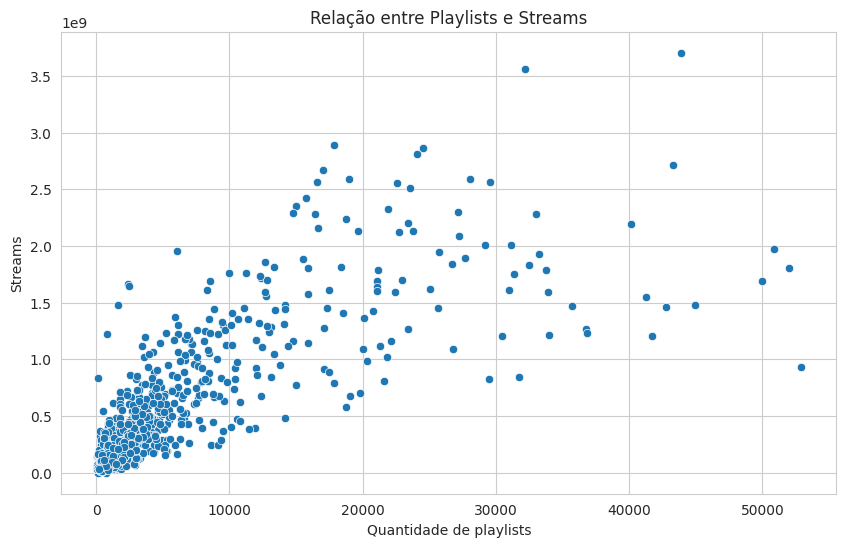

In [21]:
# Relação entre playlists e streams

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_graficos,
    x='in_spotify_playlists',
    y='streams_tratado'
)

plt.title('Relação entre Playlists e Streams')
plt.xlabel('Quantidade de playlists')
plt.ylabel('Streams')

plt.show()

### Insights

Observa-se tendência positiva entre presença em playlists e volume de streams.

Músicas incluídas em maior quantidade de playlists tendem a apresentar maiores volumes de reprodução, indicando forte influência das playlists na amplificação musical.

Entretanto, a dispersão dos pontos demonstra que outros fatores também impactam o desempenho das músicas, além da presença em playlists.

## 5.4 Heatmap de Correlação

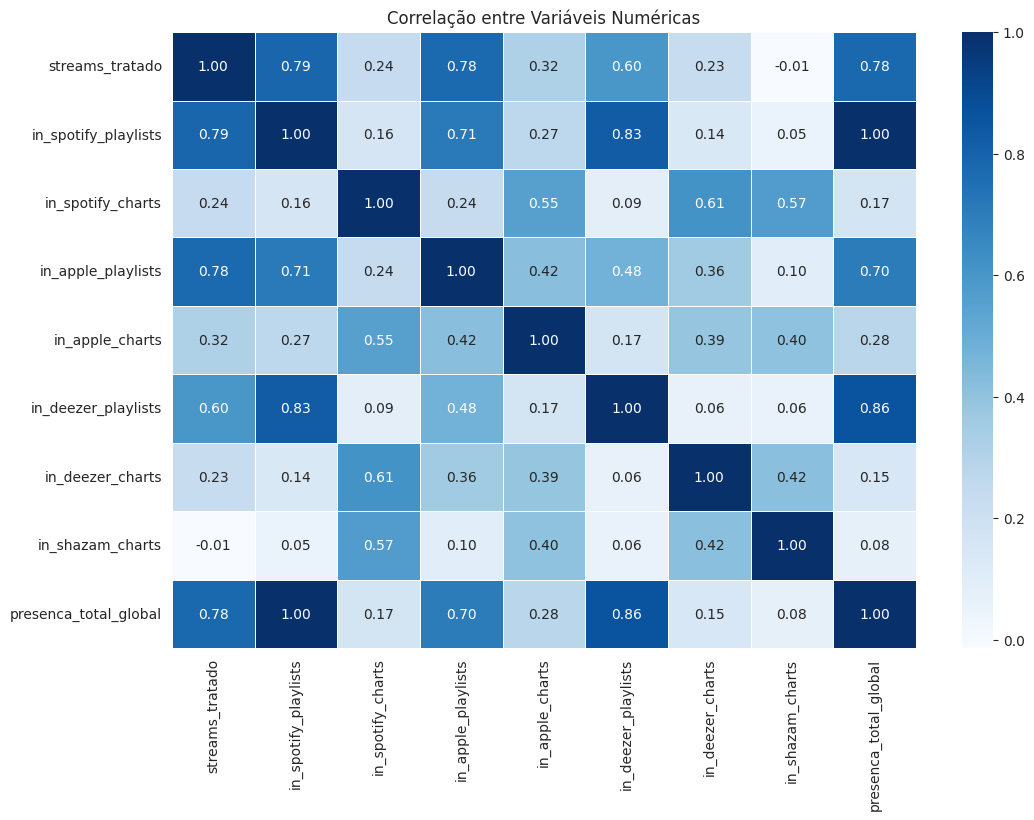

In [34]:
# Selecionando variáveis numéricas

colunas_numericas = [
    'streams_tratado',
    'in_spotify_playlists',
    'in_spotify_charts',
    'in_apple_playlists',
    'in_apple_charts',
    'in_deezer_playlists',
    'in_deezer_charts',
    'in_shazam_charts',
    'presenca_total_global'
]

correlacao = df_graficos[colunas_numericas].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlação entre Variáveis Numéricas')

plt.show()

### Insights

As variáveis relacionadas à presença em playlists apresentam correlação significativamente mais forte com streams do que variáveis relacionadas a charts.

Os resultados sugerem que playlists exercem influência mais consistente no alcance musical, enquanto presença em rankings demonstra relação mais moderada com desempenho em streams.

## 5.5 Impacto dos Charts (Boxplot)

In [30]:
df_graficos['taxa_charts'] = pd.to_numeric(
    df_graficos['taxa_charts'],
    errors='coerce'
)



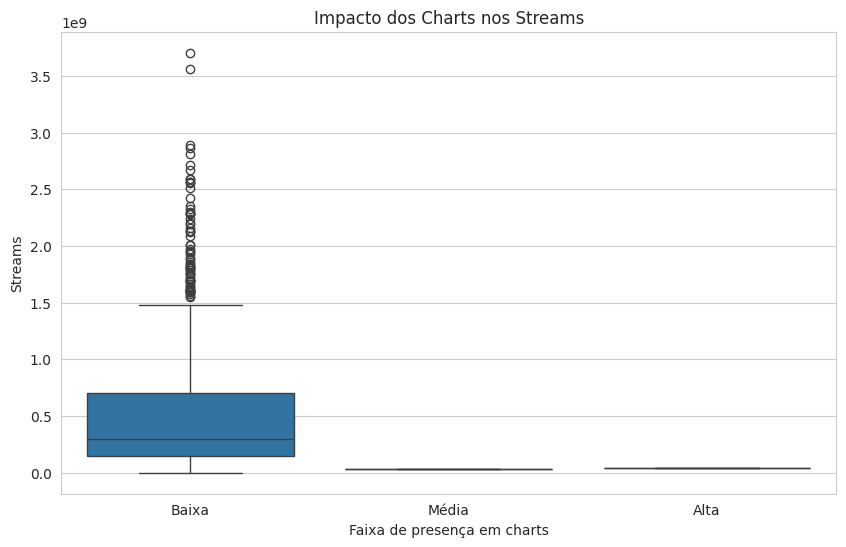

In [38]:
# Criando faixas de presença em charts

df_graficos['faixa_charts'] = pd.cut(
    df_graficos['taxa_charts'],
    bins=3,
    labels=['Baixa', 'Média', 'Alta']
)

plt.figure(figsize=(10,6))

sns.boxplot(
    x='faixa_charts',
    y='streams_tratado',
    data=df_graficos
)

plt.title('Impacto dos Charts nos Streams')
plt.xlabel('Faixa de presença em charts')
plt.ylabel('Streams')

plt.show()

### Insights

Os dados mostram forte concentração de músicas na faixa baixa de presença em charts, enquanto poucos sucessos acumulam volumes extremamente elevados de streams.

A presença de diversos outliers reforça a alta desigualdade de popularidade no consumo musical digital.

## 5.6 Presença Multiplataforma

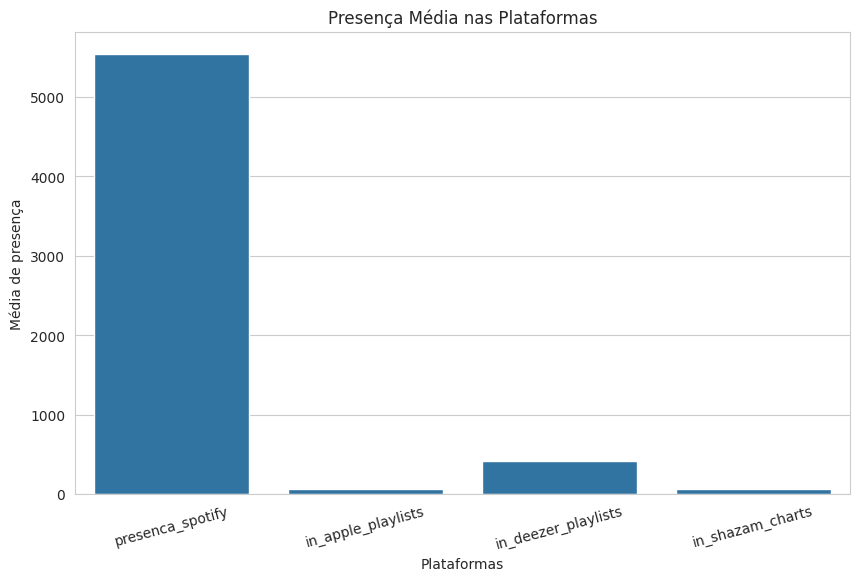

In [26]:
# Presença multiplataforma

plataformas = [
    'presenca_spotify',
    'in_apple_playlists',
    'in_deezer_playlists',
    'in_shazam_charts'
]

media_plataformas = df_graficos[plataformas].mean()

plt.figure(figsize=(10,6))

sns.barplot(
    x=media_plataformas.index,
    y=media_plataformas.values
)

plt.title('Presença Média nas Plataformas')
plt.xlabel('Plataformas')
plt.ylabel('Média de presença')

plt.xticks(rotation=15)

plt.show()

### Insights

Spotify concentra a maior presença média entre as plataformas analisadas, reforçando sua posição dominante no mercado global de streaming musical.

A análise também evidencia diferenças estruturais entre as plataformas, uma vez que Spotify possui maior escala de playlists e alcance de distribuição.

Ainda assim, a presença complementar em Apple Music, Deezer e Shazam indica que estratégias multiplataforma permanecem relevantes para expansão de alcance e descoberta musical.

## 5.7 Evolução Temporal



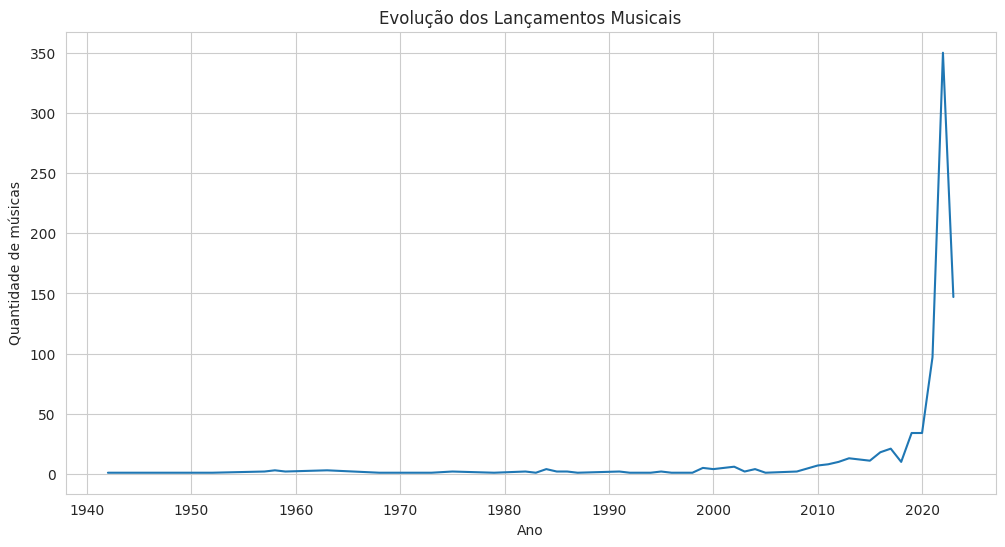

In [27]:
# Evolução temporal dos lançamentos

lancamentos_ano = (
    df_graficos['released_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=lancamentos_ano.index,
    y=lancamentos_ano.values
)

plt.title('Evolução dos Lançamentos Musicais')
plt.xlabel('Ano')
plt.ylabel('Quantidade de músicas')

plt.show()

### Insights

Observa-se crescimento expressivo do volume de lançamentos musicais nos anos mais recentes, especialmente após a consolidação das plataformas de streaming.

O comportamento sugere redução das barreiras de distribuição digital e aumento da competitividade no mercado musical contemporâneo.

# Conclusão

A análise exploratória permitiu identificar fatores relevantes associados ao desempenho musical nas plataformas de streaming.

Os resultados indicam que:

presença em playlists apresenta forte relação com volume de streams;
poucos sucessos concentram grande parte do consumo musical;
o Spotify mantém posição dominante em exposição musical;
variáveis relacionadas a playlists possuem influência mais consistente do que presença em charts;
o crescimento recente de lançamentos evidencia expansão acelerada do mercado digital.

De forma geral, os dados reforçam como visibilidade multiplataforma e curadoria em playlists desempenham papel estratégico no alcance musical contemporâneo.